# 🧬 Stage 5 · Extracting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vshabanova/bachelor/blob/main/04_feature-extraction/extracting.ipynb)

**Topic of the week:** Feature Extraction and Data Preparation · **Lecture:** Thu 01.10 · **Startup question:** *How do we describe a frame with numbers a model can learn from?*

A classic model can't look at 16 384 pixels and see a drop. We hand it a shorter, smarter description: HOG for shapes and where they are, LBP for textures. We also invent extra training frames (augmentation) and put all numbers on the same scale.

| In the CI-pipeline | |
|---|---|
| Why? | [`README.md`](README.md) |
| How? — the 🎛️ tinker zone | [`extracting_describe/action.yaml`](extracting_describe/action.yaml) |
| What? — Step 0 to 3 | [`Todo_Extracting.md`](Todo_Extracting.md) |
| 🧪 Recipe — the maths CI runs | [`extracting_describe/recipe.py`](extracting_describe/recipe.py) |
| 🧪 Sandboxes — HOG, LBP, scaling, augmentation | [`extracting_describe/sandboxes/`](extracting_describe/sandboxes/) |

This notebook imports the **same functions** CI runs, with the values from your tinker zone. Explore here, then commit your choice to the tinker zone on a branch and let CI prove it.

In [1]:
# ⚙️ Setup — works locally, in Codespaces and in Colab (Colab already has every library we need)
import os, subprocess, sys
REPO = "vshabanova/bachelor"  # filled in automatically in your own copy of the template
here = os.getcwd()
while not os.path.exists("run_pipeline.py") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                      # notebooks live in the topic folders; the pipeline root is up
if not os.path.exists("run_pipeline.py"):   # Colab: fetch the repository first
    os.chdir(here)
    if not os.path.exists("repo"):
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", "repo"], check=True)
    os.chdir("repo")
sys.path.insert(0, os.getcwd())

import cv2, json, numpy as np, matplotlib.pyplot as plt
from stages.common import load_images, to_luma
from stages.nb import prepare, run_stage, show
%matplotlib inline

✔ Stages up to 'segmenting' ran with your tinker-zone values


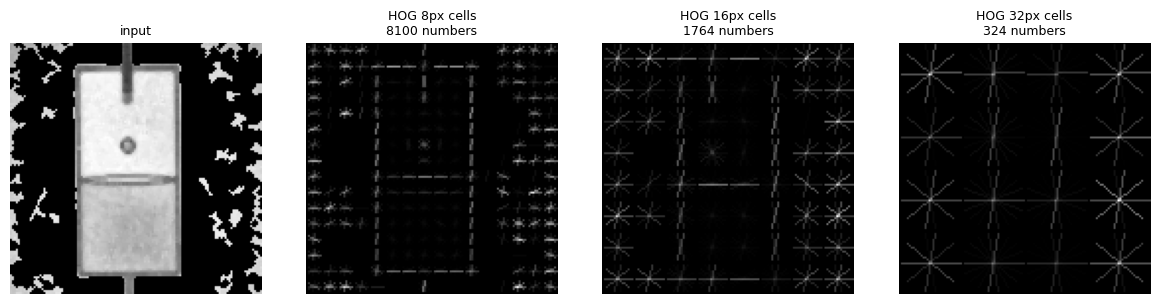

In [2]:
cfg = prepare("segmenting")
from skimage.feature import hog, local_binary_pattern
from stages.s5_extracting import augment
s4 = load_images("segmenting"); sp = s4.color_space; e = cfg["extracting"]
i = next(k for k, r in enumerate(s4.rows) if r["label"] == "drop" and r["split"] == "test")
g = to_luma(s4.images[i], sp)
vis, titles = [g], ["input"]
for ppc in (8, 16, 32):
    f, v = hog(g, orientations=9, pixels_per_cell=(ppc, ppc), cells_per_block=(2, 2), visualize=True)
    vis.append((v / v.max() * 255).astype(np.uint8)); titles.append(f"HOG {ppc}px cells\n{f.size} numbers")
show(vis, titles, size=3)

## LBP: texture codes
Every pixel is compared with its neighbours on a circle, giving a binary code. "Uniform" codes describe flat areas, edges, corners and spots.

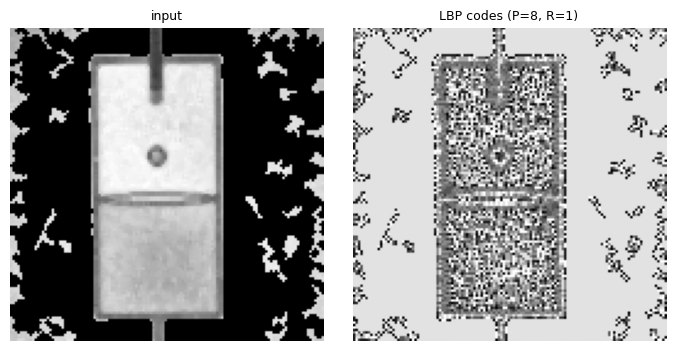

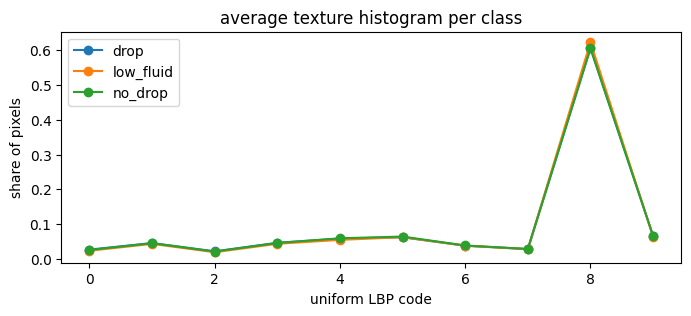

In [3]:
P, R = e["lbp_points"], e["lbp_radius"]
codes = local_binary_pattern(g, P, R, method="uniform")
show([g, (codes / codes.max() * 255).astype(np.uint8)], ["input", f"LBP codes (P={P}, R={R})"], size=3.5)
plt.figure(figsize=(8, 3))
for c in s4.classes:
    hs = [np.histogram(local_binary_pattern(to_luma(im, sp), P, R, "uniform"), bins=P + 2, range=(0, P + 2), density=True)[0]
          for im, r in zip(s4.images, s4.rows) if r["label"] == c]
    plt.plot(np.mean(hs, 0), "o-", label=c)
plt.xlabel("uniform LBP code"); plt.ylabel("share of pixels"); plt.title("average texture histogram per class"); plt.legend(); plt.show()

## Augmentation: plausible fake frames
Each augmented frame should look like something the real camera could produce. The last one doesn't.

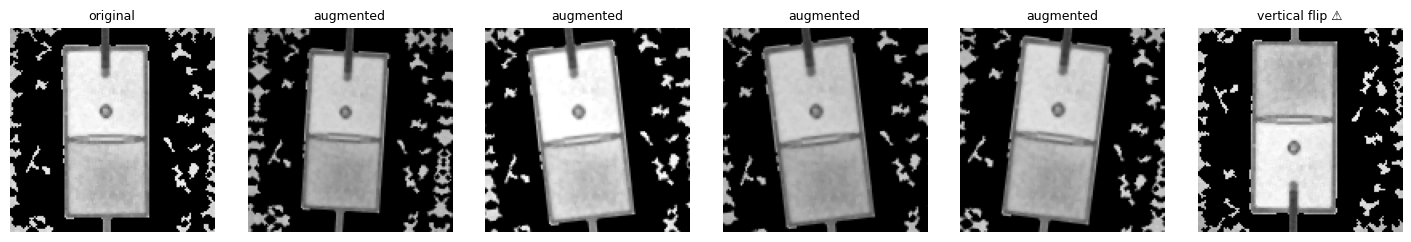

In [4]:
rng = np.random.default_rng(0)
frame = s4.images[i]
show([frame] + [augment(frame, e, rng) for _ in range(4)] + [cv2.flip(frame, 0)],
     ["original"] + ["augmented"] * 4 + ["vertical flip ⚠"], color_space=sp, size=2.4)

## Why stage 5 keeps track of *groups*
An augmented copy is nearly the same frame as its original. If ordinary cross-validation puts the original in the training fold and its copy in the validation fold, the model is graded on a frame it has already seen.

In [5]:
run_stage("extracting")
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_score
d = np.load("build/extracting/features.npz")
X, y, groups = d["X_train"], d["y_train"], d["g_train"]
rf = RandomForestClassifier(100, random_state=0, n_jobs=-1)
leaky = cross_val_score(rf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=0)).mean()
honest = cross_val_score(rf, X, y, groups=groups, cv=StratifiedGroupKFold(5, shuffle=True, random_state=0)).mean()
test = rf.fit(X, y).score(d["X_test"], d["y_test"])
print(f"CV, copies may leak across folds : {leaky:.3f}\nCV, copies kept together (groups): {honest:.3f}\nlocked test set                  : {test:.3f}")

CV, copies may leak across folds : 0.907
CV, copies kept together (groups): 0.889
locked test set                  : 0.978


## 🧪 Your turn
1. Set `hog.pixels_per_cell: 4`. How many features? Which gate fails, and is that gate a technical or a business decision?
2. Look at the LBP plot. Which class stands out, and which two are hard to tell apart with texture alone? Test `features: [lbp]`.
3. Turn on `flip_vertical`. Predict the effect first, then check the Demo Day table.
4. With `augment.copies: 0`, is the leaky CV score still higher than the honest one? Why?

## 🚀 Ship your choice

1. Create a branch: `experiment/<what-you-change>`
2. Change **one** value in the 🎛️ TINKER ZONE of this topic's `action.yaml`
3. Push and open a pull request. The PR template asks for your hypothesis and result.
4. Compare the 🎤 Demo Day table of your PR with the one on `main`. Better? Merge. Not better? Close it and write down why — that's R&D too.